# 2D Transient Heat Equation for Gold

This notebook solves the temperature field on the central 2D section of a spherical gold particle. The model keeps the in-plane heat diffusion terms and uses the same spherical source and radiation normalization as the 3D notebook:

$$
\rho C_P \frac{\partial T}{\partial t}
= k\left(\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2}\right)
- \frac{4\pi R_\mathrm{sphere}^2}{V_\mathrm{sphere}}\varepsilon\sigma\left(T^4 - T_0^4\right)
+ Q_{3D}(x,y).
$$

The heat source is built directly from `Scorer_1.csv`. The scorer values provide the relative spatial deposition shape on this 2D section, then the source is scaled so its mean inside the circular gold domain equals the spherical mean deposited power density:

$$
\langle Q_{3D}\rangle = \frac{P_\mathrm{dep}}{V_\mathrm{sphere}},
\qquad
P_\mathrm{dep} = \frac{E_P I}{e_c}.
$$

Here $I$ is the total beam current, currently $50\,\mathrm{nA}$. No current-density source term, projected-area source scaling, or $R_\mathrm{KO}$ depth scale is used.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

In [2]:
# Physical constants
e_c = 1.602176634e-19
sigma_SB = 5.670374419e-8

# Beam parameters
E_beam_keV = 300.0
deposited_fraction = 0.0071
E_P_keV = E_beam_keV * deposited_fraction
E_P_J = E_P_keV * 1e3 * e_c
I_total = 50.0e-9
T0 = 300.0

# Deposited beam power [W] = deposited energy per electron [J] * current [A] / e_c [C]
P_dep_total = E_P_J * I_total / e_c

# Gold properties
rho_Au = 19.32e3
Cp_Au = 129.0
k_Au = 317.0
eps_Au = 1.0
T_sublimate_Au = 1275.0
alpha_Au = k_Au / (rho_Au * Cp_Au)

print(f'E_P = {E_P_keV:.4f} keV = {E_P_J:.4e} J per electron')
print(f'I_total = {I_total * 1e9:.2f} nA')
print(f'P_dep = E_P*I/e_c = {P_dep_total:.3e} W')
print(f'alpha_Au = {alpha_Au:.3e} m^2/s')


E_P = 2.1300 keV = 3.4126e-16 J per electron
I_total = 50.00 nA
P_dep = E_P*I/e_c = 1.065e-04 W
alpha_Au = 1.272e-04 m^2/s


## Calculate Scorer-Based $Q_{3D}(x,y)$

The volumetric beam-heating source is taken from `Scorer_1.csv`. The scorer values are interpolated onto the heat-equation grid and used as the relative spatial deposition shape. The source is normalized so its mean inside the circular section equals the spherical mean deposited power density, $P_\mathrm{dep}/V_\mathrm{sphere}$, with $P_\mathrm{dep} = E_P I/e_c$.


In [3]:
# Spatial grid
Nx, Ny = 100, 100
Lx = Ly = 1.0e-6
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
x = np.linspace(0.0, Lx, Nx)
y = np.linspace(0.0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# Circular gold section through the 500 nm radius sphere.
xc = Lx / 2.0
yc = Ly / 2.0
R_sphere = Lx / 2.0
R_disk = R_sphere
r_xy_grid = np.sqrt((X - xc)**2 + (Y - yc)**2)
disk_mask = r_xy_grid <= R_disk

# Scorer-based volumetric source from the original 2D scorer.
scorer_path = 'Scorer_1.csv'
scorer = pd.read_csv(scorer_path, usecols=['X', 'Y', 'Edep'])
center_index = int(round(scorer['Y'].median()))

source_x = np.sort(scorer['X'].unique()) / 199.0 * Lx
source_y = (np.sort(scorer['Y'].unique()) - center_index) / 200.0 * Ly
source_values = (
    scorer.sort_values(['X', 'Y'])['Edep']
    .to_numpy(dtype=float)
    .reshape(len(source_x), len(source_y))
)

source_interpolator = RegularGridInterpolator(
    (source_x, source_y),
    source_values,
    bounds_error=False,
    fill_value=0.0,
)
raw_source = source_interpolator(
    np.column_stack([X.ravel(), (Y - yc).ravel()])
).reshape(Nx, Ny)
raw_source = np.where(disk_mask, raw_source, 0.0)

mean_in_disk = raw_source[disk_mask].mean()
if mean_in_disk <= 0.0:
    raise ValueError('Scorer-based source has zero mean inside the disk')

V_sphere = 4.0 / 3.0 * np.pi * R_sphere**3
Q_sphere_mean = P_dep_total / V_sphere
Q3D = np.where(disk_mask, Q_sphere_mean * raw_source / mean_in_disk, 0.0)

# Same spherical radiative cooling model as the 3D notebook.
A_surface = 4.0 * np.pi * R_sphere**2
rad_coeff = eps_Au * sigma_SB * A_surface / V_sphere

print(f'Grid: {Nx} x {Ny}, dx = {dx * 1e9:.2f} nm')
print(f'R_sphere = {R_sphere * 1e9:.1f} nm')
print(f'V_sphere = {V_sphere * 1e18:.3f} um^3')
print(f'A_surface = {A_surface * 1e12:.3f} um^2')
print(f'Scorer source: {scorer_path}, center Y index = {center_index}')
print(f'P_dep = {P_dep_total:.3e} W  (I_total = {I_total * 1e9:.2f} nA)')
print(f'Q sphere mean = {Q_sphere_mean:.3e} W/m^3')
print(f'Q3D mean inside disk = {Q3D[disk_mask].mean():.3e} W/m^3')
print(f'Q3D peak = {Q3D.max():.3e} W/m^3')
print(f'rad_coeff = {rad_coeff:.3e} W/(m^3 K^4)')


Grid: 100 x 100, dx = 10.10 nm
R_sphere = 500.0 nm
V_sphere = 0.524 um^3
A_surface = 3.142 um^2
Scorer source: Scorer_1.csv, center Y index = 100
P_dep = 1.065e-04 W  (I_total = 50.00 nA)
Q sphere mean = 2.034e+14 W/m^3
Q3D mean inside disk = 2.034e+14 W/m^3
Q3D peak = 1.229e+16 W/m^3
rad_coeff = 3.402e-01 W/(m^3 K^4)


## Explicit FTCS Time Integration\n
\n
Only cells inside the circular disk are updated. Outside-disk cells are reset to $T_0$ after each step.

In [4]:
dt_crit = min(dx, dy)**2 / (4.0 * alpha_Au)
dt = 0.4 * dt_crit
t_end = 1.5e-9
N_steps = int(np.ceil(t_end / dt))
dt = t_end / N_steps

T = np.full((Nx, Ny), T0, dtype=np.float64)
Tp = np.empty((Nx + 2, Ny + 2))
ic, jc = Nx // 2, Ny // 2
sample_every = max(1, N_steps // 1000)
t_hist = []
T_center_hist = []

print(f'dt = {dt:.3e} s, N_steps = {N_steps}')

for n in range(N_steps + 1):
    if n % sample_every == 0 or n == N_steps:
        t_hist.append(n * dt)
        T_center_hist.append(T[ic, jc])

    if n == N_steps:
        break

    Tp[1:-1, 1:-1] = T
    Tp[0, 1:-1] = T[0, :]
    Tp[-1, 1:-1] = T[-1, :]
    Tp[1:-1, 0] = T[:, 0]
    Tp[1:-1, -1] = T[:, -1]

    lap = ((Tp[2:, 1:-1] - 2.0 * T + Tp[:-2, 1:-1]) / dx**2 +
           (Tp[1:-1, 2:] - 2.0 * T + Tp[1:-1, :-2]) / dy**2)

    rad = np.where(disk_mask, rad_coeff * (T**4 - T0**4), 0.0)
    T += dt * (k_Au * lap - rad + Q3D) / (rho_Au * Cp_Au)
    T[~disk_mask] = T0

t_hist = np.asarray(t_hist)
T_center_hist = np.asarray(T_center_hist)

print(f'T_center(t_end) = {T[ic, jc]:.2f} K')
print(f'T_max inside disk = {T[disk_mask].max():.2f} K')
print(f'T_sublimate = {T_sublimate_Au:.0f} K')

dt = 8.021e-14 s, N_steps = 18700
T_center(t_end) = 300.07 K
T_max inside disk = 300.07 K
T_sublimate = 1275 K


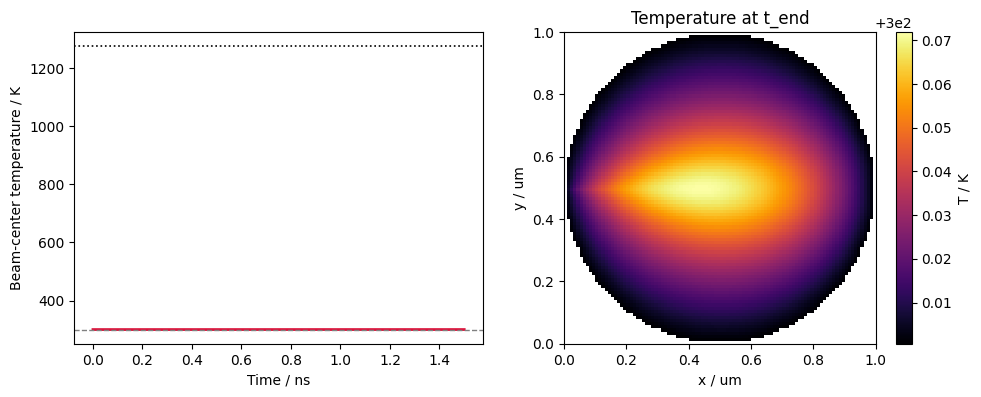

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(t_hist * 1e9, T_center_hist, color='crimson', lw=2)
axes[0].axhline(T0, color='0.5', ls='--', lw=1)
axes[0].axhline(T_sublimate_Au, color='black', ls=':', lw=1.2)
axes[0].set_xlabel('Time / ns')
axes[0].set_ylabel('Beam-center temperature / K')

im = axes[1].imshow(
    np.where(disk_mask, T, np.nan).T,
    origin='lower',
    extent=[0, Lx * 1e6, 0, Ly * 1e6],
    cmap='inferno',
)
axes[1].set_xlabel('x / um')
axes[1].set_ylabel('y / um')
axes[1].set_title('Temperature at t_end')
fig.colorbar(im, ax=axes[1], label='T / K')

fig.tight_layout()
plt.show()